In [2]:
#relevant libraries
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt
import sklearn.linear_model as sk

In [3]:
#preprocessing
url = "https://www.kaggle.com/datasets/zalando-research/fashionmnist/data"
file_path = "mnist.npz"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

with np.load(file_path) as data:
    x_train, y_train = data['x_train'], data['y_train']
    x_test, y_test = data['x_test'], data['y_test']

train_mask = np.isin(y_train, [0, 1, 2])
test_mask = np.isin(y_test, [0, 1, 2])

x_train_filtered = x_train[train_mask]
y_train_filtered = y_train[train_mask]

x_test_filtered = x_test[test_mask]
y_test_filtered = y_test[test_mask]

x_train_flat = x_train_filtered.reshape(x_train_filtered.shape[0], -1)
x_test_flat = x_test_filtered.reshape(x_test_filtered.shape[0], -1)

x_train_processed = x_train_flat.astype(np.float32) / 255.0
x_test_processed = x_test_flat.astype(np.float32) / 255.0

print(f"Original Training set shape: {x_train.shape}, {y_train.shape}")
print(f"Original Test set shape: {x_test.shape}, {y_test.shape}")
print()
print(f"Filtered Training set shape (classes 0, 1, 2): {x_train_filtered.shape}, {y_train_filtered.shape}")
print(f"Filtered Test set shape (classes 0, 1, 2): {x_test_filtered.shape}, {y_test_filtered.shape}")
print()
print(f"Processed Training set shape (flattened): {x_train_processed.shape}")
print(f"Processed Test set shape (flattened): {x_test_processed.shape}")
print(f"Pixel value range: [{x_train_processed.min()}, {x_train_processed.max()}]")

Original Training set shape: (60000, 28, 28), (60000,)
Original Test set shape: (10000, 28, 28), (10000,)

Filtered Training set shape (classes 0, 1, 2): (18623, 28, 28), (18623,)
Filtered Test set shape (classes 0, 1, 2): (3147, 28, 28), (3147,)

Processed Training set shape (flattened): (18623, 784)
Processed Test set shape (flattened): (3147, 784)
Pixel value range: [0.0, 1.0]


In [4]:
def compute_mean(data_matrix):
    return np.mean(data_matrix, axis=0)

def compute_covariance(data_matrix):
    N = data_matrix.shape[0]
    return (data_matrix.T @ data_matrix) / (N - 1)
    
def pca(samples, variance=1.0, components=0):
    print(f"Training set shape ({samples.shape[0]},{samples.shape[1]})")
    
    # Calculate mean and center data
    mean = compute_mean(samples)
    print(f"Mean shape {mean.shape}")
    centered_data_mat = samples - mean
    print(f"Centered data matrix shape {centered_data_mat.shape}")
    
    # Compute covariance matrix
    covariance = compute_covariance(centered_data_mat)
    print(f"Centered data matrix shape {covariance.shape}")
    
    # Solve eigenvalue problem (eigh is optimal for symmetric covariance matrices)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    # Vectorized cleanup of negative eigenvalues caused by computational float errors
    eigenvalues = np.maximum(eigenvalues, 0)
            
    # Sort eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    sorted_eigenvalues = eigenvalues[sorted_indices]

    # Variance Preservation Threshold
    if 0 < variance < 1:
        explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
        cumulative_variance = np.cumsum(explained_variance_ratio)
        
        retain_indices = np.argmax(cumulative_variance >= variance) + 1
        return sorted_eigenvectors[:, :retain_indices]

    # Fixed Number of Components
    elif 0 < components < sorted_eigenvectors.shape[1]:
        return sorted_eigenvectors[:, :components]

    return sorted_eigenvectors

def apply_pca(samples, w, mean):
    samples = samples - mean
    return samples @ w

In [5]:
w_pca = pca(x_train_processed, components=10)
reduced_dim_x_train = apply_pca(x_train_processed, w_pca, np.mean(x_train_processed, axis = 0))
reduced_dim_x_test = apply_pca(x_test_processed, w_pca, np.mean(x_train_processed, axis = 0))

Training set shape (18623,784)
Mean shape (784,)
Centered data matrix shape (18623, 784)
Centered data matrix shape (784, 784)


In [37]:
def calc_ssr(y_left, y_right):
    mean_left = np.mean(y_left)
    mean_right = np.mean(y_right)
    
    ssr_left = np.sum((y_left - mean_left) ** 2)
    ssr_right = np.sum((y_right - mean_right) ** 2)
    
    return ssr_left + ssr_right

def regression_stump(X_train, y_train):
    stump = {}
    best_ssr = float('inf')
    
    for feature in range(X_train.shape[1]):
        feature_values = X_train[:, feature]
        unique_sorted_vals = np.sort(np.unique(feature_values))
        
        if len(unique_sorted_vals) > 1:
            midpoints = (unique_sorted_vals[:-1] + unique_sorted_vals[1:]) / 2
        else:
            continue 
            
        for threshold in midpoints:            
            y_left = y_train[feature_values <= threshold]
            y_right = y_train[feature_values > threshold]
            
            ssr = calc_ssr(y_left, y_right)
            
            if ssr < best_ssr:
                best_ssr = ssr
                stump = {'feature':feature, 'threshold':threshold, 'left': np.mean(y_left), 'right': np.mean(y_right)}
                
    return stump

def predict(stump, X):
    predictions = np.zeros(X.shape[0])
        
    # Apply the single split to all samples
    left_mask = X[:, stump['feature']] <= stump['threshold']
    right_mask = X[:, stump['feature']] > stump['threshold']
    
    predictions[left_mask] = stump['left']
    predictions[right_mask] = stump['right']
    
    return predictions

In [52]:
stump = regression_stump(reduced_dim_x_train, y_train_filtered)
y_pred_stump = predict(stump, reduced_dim_x_test)

#report test mse
test_mse = np.mean((y_test_filtered - y_pred_stump) ** 2)
print(f"Test Set MSE (Single Stump): {test_mse}")       

Test Set MSE (Single Stump): 0.3545891395603466


In [54]:
def train_bagged_stumps(X_train, y_train, X_test, y_test, num_models=5):
    m_total = len(y_train)
    bagged_models = []
    oob_errors = []
    test_predictions_all = []

    for i in range(num_models):
        bootstrap_indices = np.random.choice(m_total, size=m_total, replace=True)
        X_boot = X_train[bootstrap_indices]
        y_boot = y_train[bootstrap_indices]
        
        all_indices = np.arange(m_total)
        oob_indices = np.setdiff1d(all_indices, bootstrap_indices)
        X_oob = X_train[oob_indices]
        y_oob = y_train[oob_indices]
        
        stump_i = regression_stump(X_boot, y_boot)
        bagged_models.append(stump_i)
        
        if len(oob_indices) > 0:
            y_oob_pred = predict(stump_i, X_oob)
            oob_mse = np.mean((y_oob - y_oob_pred) ** 2)
            oob_errors.append(oob_mse)
            
        test_predictions_all.append(predict(stump_i, X_test))
        
    avg_oob_error = np.mean(oob_errors)
    print(f"Average Out-of-Bag (OOB) MSE: {avg_oob_error:.4f}")

    #bagging test mse
    bagged_test_preds = np.mean(test_predictions_all, axis=0)
    bagged_test_mse = np.mean((y_test - bagged_test_preds) ** 2)
    print(f"Test Set MSE (Bagging): {bagged_test_mse:}")
    
    return bagged_models, bagged_test_preds

Average Out-of-Bag (OOB) MSE: 0.3600
Test Set MSE (Bagging): 0.3521383559603276


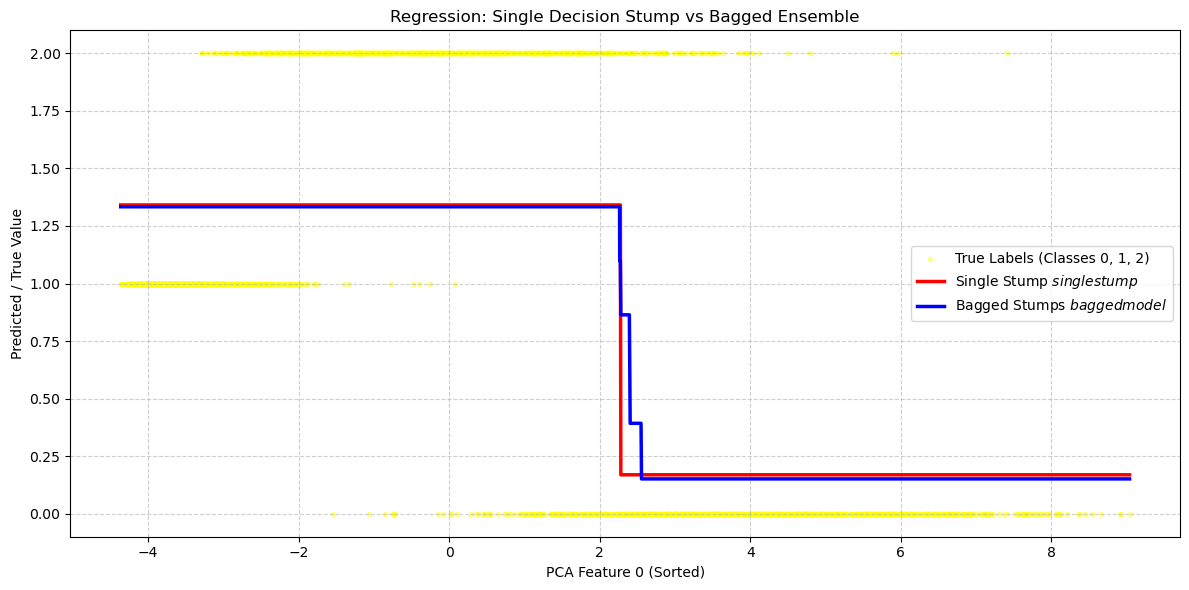

In [55]:
bagged_models, y_pred_bagged = train_bagged_stumps(reduced_dim_x_train, y_train_filtered, reduced_dim_x_test, y_test_filtered)
split_feature = stump['feature']
sorted_indices = np.argsort(reduced_dim_x_test[:, split_feature])

x_plot = reduced_dim_x_test[sorted_indices, split_feature]
y_true_plot = y_test_filtered[sorted_indices]
y_stump_plot = y_pred_stump[sorted_indices]
y_bagged_plot = y_pred_bagged[sorted_indices]

plt.figure(figsize=(12, 6))

plt.scatter(x_plot, y_true_plot, color='yellow', label='True Labels (Classes 0, 1, 2)', alpha=0.4, marker='.')

plt.plot(x_plot, y_stump_plot, color='red', label='Single Stump $single stump$', linewidth=2.5)
plt.plot(x_plot, y_bagged_plot, color='blue', label='Bagged Stumps $bagged model$', linewidth=2.5)

plt.xlabel(f'PCA Feature {split_feature} (Sorted)')
plt.ylabel('Predicted / True Value')
plt.title('Regression: Single Decision Stump vs Bagged Ensemble')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Average Out-of-Bag (OOB) MSE: 0.3592
Test Set MSE (Bagging): 0.3544353137214656


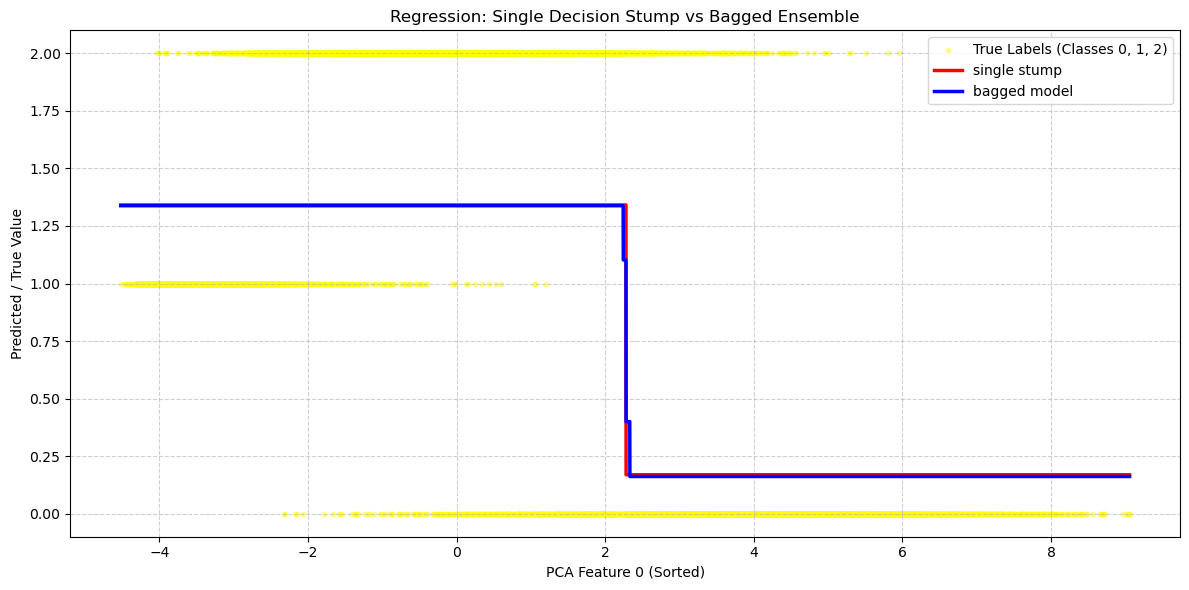

In [56]:
bagged_models, y_pred_bagged = train_bagged_stumps(reduced_dim_x_train, y_train_filtered, reduced_dim_x_train, y_train_filtered)
# 1. Identify the feature the single stump used to split
split_feature = stump['feature']
y_pred_stump = predict(stump, reduced_dim_x_train)

# 2. Sort the TEST data based on this feature for a clean line plot
# Make sure to use your test set variables here!
sorted_indices = np.argsort(reduced_dim_x_train[:, split_feature])

# 3. Apply the sorted test indices to all test arrays
x_plot = reduced_dim_x_train[sorted_indices, split_feature]
y_true_plot = y_train_filtered[sorted_indices]
y_stump_plot = y_pred_stump[sorted_indices]
y_bagged_plot = y_pred_bagged[sorted_indices]

# 4. Create the plot
plt.figure(figsize=(12, 6))

# Plot True Function (Labels) as scatter points
plt.scatter(x_plot, y_true_plot, color='yellow', label='True Labels (Classes 0, 1, 2)', alpha=0.4, marker='.')

# Plot Single Stump
plt.plot(x_plot, y_stump_plot, color='red', label='single stump', linewidth=2.5)

# Plot Bagged Model
plt.plot(x_plot, y_bagged_plot, color='blue', label='bagged model', linewidth=2.5)

plt.xlabel(f'PCA Feature {split_feature} (Sorted)')
plt.ylabel('Predicted / True Value')
plt.title('Regression: Single Decision Stump vs Bagged Ensemble')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()